In [1]:
import numpy as np
import pandas as pd
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# --- Load price data ---
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]

# --- Load universe trading days ---
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(
    excelFile=universeFilePath,
    sheetName='Sheet1',
    startDate=closeDf.first_valid_index()
)
allTradingDatesDf.reset_index(drop=True, inplace=True)

mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

In [3]:
# --- Add weekly grouping ---
allTradingDatesDf["YearWeek"] = allTradingDatesDf["Date"].dt.strftime("%Y-%U")

# --- Find the last trading day of each week ---
weeklyEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby("YearWeek")["Date"].idxmax()]
weeklyEndDatesDf.sort_values(by="Date", inplace=True)

# Read the Excel file
rebal_df = pd.read_excel(r'D:\Linear Model\data\RSI\Final\NSEI\W_allRebal.xlsx')

# Make sure the 'Date' column is datetime type
rebal_df['Date'] = pd.to_datetime(rebal_df['Date'])

# --- Define weekly rebalancing period: Jan 2020 → last available trading day ---
start_date = pd.Timestamp("2010-01-01")
end_date = closeMergedDf.index.max()  # last available date from your price data

monthly_rebal_df = rebal_df[(rebal_df['Date'] >= start_date) & (rebal_df['Date'] <= end_date)]

# Keep the first rebal date in each month
first_rebal_of_month_df = (
    monthly_rebal_df.loc[
        monthly_rebal_df.groupby(rebal_df['Date'].dt.to_period('M'))['Date'].idxmin()
    ]
    .reset_index(drop=True)
)

rebalDates = first_rebal_of_month_df['Date'].tolist()

print(f"Total first rebal dates per month: {len(rebalDates)}")
print("First 5:", rebalDates[:5])
print("Last 5:", rebalDates[-5:])


Total first rebal dates per month: 189
First 5: [Timestamp('2010-01-08 00:00:00'), Timestamp('2010-02-06 00:00:00'), Timestamp('2010-03-05 00:00:00'), Timestamp('2010-04-01 00:00:00'), Timestamp('2010-05-07 00:00:00')]
Last 5: [Timestamp('2025-05-02 00:00:00'), Timestamp('2025-06-06 00:00:00'), Timestamp('2025-07-04 00:00:00'), Timestamp('2025-08-01 00:00:00'), Timestamp('2025-09-05 00:00:00')]


In [4]:
returns = closeMergedDf.pct_change().dropna()
realized_var = returns ** 2  # daily realized variance

# Replace price series with realized variance
rvDf = realized_var.rename(columns={realized_var.columns[0]: 'RV'})  # single column for matching

In [5]:
window_size = 45  # lookback window for matching
indexLists = [0, 1, 2, 3, 4]  # indices to plot
top_regimes = []

for i, rebalDate in enumerate(rebalDates):
    print(f"\nProcessing rebal date: {rebalDate}")

    # --- Match regimes on realized variance instead of price
    sim = mk.Match(rvDf, rebalDate, windowSize=window_size, threshold=0.50)
    reg = sim.getRegime()
    if reg.empty:
        print("No matching regimes found. Skipping this date.")
        continue

    # --- Keep top 5 motifs
    top5 = reg.head(5).copy()
    top5["RebalDate"] = rebalDate
    top_regimes.append(top5)

    # # --- Optional: plot z-scored realized variance motifs
    # plt.figure(figsize=(24, 6))
    # ax = plt.gca()
    # for idx in range(min(5, len(top5))):
    #     ax.plot(
    #         stats.zscore(rvDf.loc[top5.iloc[idx].start:top5.iloc[idx].end].values),
    #         label=f"{top5.iloc[idx].start} to {top5.iloc[idx].end}"
    #     )
    # ax.legend()
    # plt.title(f"Top 5 RV-Matched Regimes for {rebalDate}")
    # plt.show()

top_regimes_df = pd.concat(top_regimes, ignore_index=True)



Processing rebal date: 2010-01-08 00:00:00

Processing rebal date: 2010-02-06 00:00:00

Processing rebal date: 2010-03-05 00:00:00

Processing rebal date: 2010-04-01 00:00:00

Processing rebal date: 2010-05-07 00:00:00

Processing rebal date: 2010-06-04 00:00:00

Processing rebal date: 2010-07-02 00:00:00

Processing rebal date: 2010-08-06 00:00:00

Processing rebal date: 2010-09-03 00:00:00

Processing rebal date: 2010-10-01 00:00:00

Processing rebal date: 2010-11-05 00:00:00

Processing rebal date: 2010-12-03 00:00:00

Processing rebal date: 2011-01-07 00:00:00

Processing rebal date: 2011-02-04 00:00:00

Processing rebal date: 2011-03-04 00:00:00

Processing rebal date: 2011-04-01 00:00:00

Processing rebal date: 2011-05-06 00:00:00

Processing rebal date: 2011-06-03 00:00:00

Processing rebal date: 2011-07-01 00:00:00

Processing rebal date: 2011-08-05 00:00:00

Processing rebal date: 2011-09-02 00:00:00

Processing rebal date: 2011-10-07 00:00:00

Processing rebal date: 2011-11-

In [6]:
top_regimes_df.isna().sum()

idx          0
start        0
end          0
dp           0
RebalDate    0
dtype: int64

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# --- Ensure datetimes
closeMergedDf = closeMergedDf.copy()
closeMergedDf.index = pd.to_datetime(closeMergedDf.index)

top_regimes_df["start"] = pd.to_datetime(top_regimes_df["start"])
top_regimes_df["end"] = pd.to_datetime(top_regimes_df["end"])

# --- Prepare columns for post-motif stats
stats_cols = ["MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]
for col in stats_cols:
    top_regimes_df[col] = np.nan

# --- Loop through motifs
for idx, row in top_regimes_df.iterrows():
    end_date = row["end"]

    # Get calendar 1-month window after motif end
    next_month_end = end_date + pd.DateOffset(months=1)

    # Get data within that window
    mask = (closeMergedDf.index > end_date) & (closeMergedDf.index <= next_month_end)
    next_month_prices = closeMergedDf.loc[mask].iloc[:, 0]  # first column

    if len(next_month_prices) < 5:
        continue  # skip if not enough data

    # Compute daily returns
    returns = next_month_prices.pct_change().dropna()

    # --- Calculate stats ---
    mean_ret = returns.mean()
    vol = returns.std()  # daily volatility
    realized_vol = np.sum(returns ** 2)
    skew_val = skew(returns)
    kurt_val = kurtosis(returns, fisher=True)  # Fisher=True → 0 for normal dist.

    # Store results
    top_regimes_df.at[idx, "MeanRet_1M"] = mean_ret
    top_regimes_df.at[idx, "Vol_1M"] = vol
    top_regimes_df.at[idx, "RealizedVol_1M"] = realized_vol
    top_regimes_df.at[idx, "Skew_1M"] = skew_val
    top_regimes_df.at[idx, "Kurt_1M"] = kurt_val

# --- Inspect result
print(top_regimes_df[
          ["RebalDate", "start", "end", "MeanRet_1M", "Vol_1M", "RealizedVol_1M", "Skew_1M", "Kurt_1M"]].head())

   RebalDate      start        end  MeanRet_1M    Vol_1M  RealizedVol_1M  \
0 2010-01-08 2006-09-22 2006-11-28    0.000645  0.015081        0.004329   
1 2010-01-08 2001-08-29 2001-11-02    0.004435  0.012544        0.002852   
2 2010-01-08 1999-10-21 1999-12-23    0.005836  0.025065        0.011956   
3 2010-01-08 2006-02-02 2006-04-12    0.004457  0.013860        0.004047   
4 2010-01-08 2003-02-07 2003-04-16    0.001806  0.006799        0.000894   

    Skew_1M   Kurt_1M  
0 -1.048921  0.208365  
1  0.265390 -0.307698  
2  0.837610  1.431205  
3 -0.230165 -0.434923  
4 -0.171406 -1.094434  


In [8]:
from scipy.stats.mstats import winsorize

def winsorize_series(series, lower=0.01, upper=0.01):
    """Winsorize a pandas Series safely, preserving NaNs."""
    if series.isnull().all():
        return series
    s = series.copy()
    non_na = s.dropna()
    w = winsorize(non_na, limits=[lower, upper])
    s.loc[non_na.index] = w
    return s

# Winsorize distance metric dp (top 1% only)
if "dp" in top_regimes_df.columns:
    top_regimes_df["dp"] = winsorize_series(top_regimes_df["dp"], lower=0, upper=0.01)

print("Winsorization complete. Proceeding with correlation and calibration analysis.")

Winsorization complete. Proceeding with correlation and calibration analysis.


In [9]:
# Ensure dp column exists
assert "dp" in top_regimes_df.columns, "Missing 'dp' column — required for weighting."

# Function to compute weighted average where smaller dp → higher weight
def weighted_avg(df, value_col, weight_col="dp"):
    # Drop NaN values
    df = df[[value_col, weight_col]].dropna()
    if df.empty:
        return np.nan

    # Compute inverse-distance weights
    inv_w = 1 / df[weight_col]
    weights = inv_w / inv_w.sum()

    return np.sum(df[value_col] * weights)

# --- Compute weighted averages for each rebal date
agg_list = []
for rebal, group in top_regimes_df.groupby("RebalDate"):
    result = {"RebalDate": rebal}

    # Weighted averages (you can include more metrics)
    result["WgtVol_1M"] = weighted_avg(group, "Vol_1M")
    result["WgtMeanRet_1M"] = weighted_avg(group, "MeanRet_1M")
    result["WgtRealizedVol_1M"] = weighted_avg(group, "RealizedVol_1M")
    result["WgtSkew_1M"] = weighted_avg(group, "Skew_1M")
    result["WgtKurt_1M"] = weighted_avg(group, "Kurt_1M")

    agg_list.append(result)

# Combine into DataFrame
rebal_weighted_stats = pd.DataFrame(agg_list).sort_values("RebalDate")

# --- Inspect results
print(rebal_weighted_stats.head())

# --- Optional: Save to file
#rebal_weighted_stats.to_csv("rebal_weighted_volatility.csv", index=False)


   RebalDate  WgtVol_1M  WgtMeanRet_1M  WgtRealizedVol_1M  WgtSkew_1M  \
0 2010-01-08   0.014687       0.003401           0.004804   -0.081864   
1 2010-02-06   0.017916       0.001714           0.008004    0.268353   
2 2010-03-05   0.017297       0.000769           0.006576    0.347760   
3 2010-04-01   0.014648       0.002315           0.004428    0.155311   
4 2010-05-07   0.015360       0.001410           0.005304   -0.141396   

   WgtKurt_1M  
0   -0.032778  
1   -0.322796  
2   -0.311535  
3   -0.659711  
4    0.417394  


In [10]:
# Winsorize volatility metrics (1st and 99th percentiles)
for col in ["WgtVol_1M","WgtRealizedVol_1M"]:
    if col in rebal_weighted_stats.columns:
        rebal_weighted_stats[col] = winsorize_series(rebal_weighted_stats[col], lower=0.01, upper=0.01)

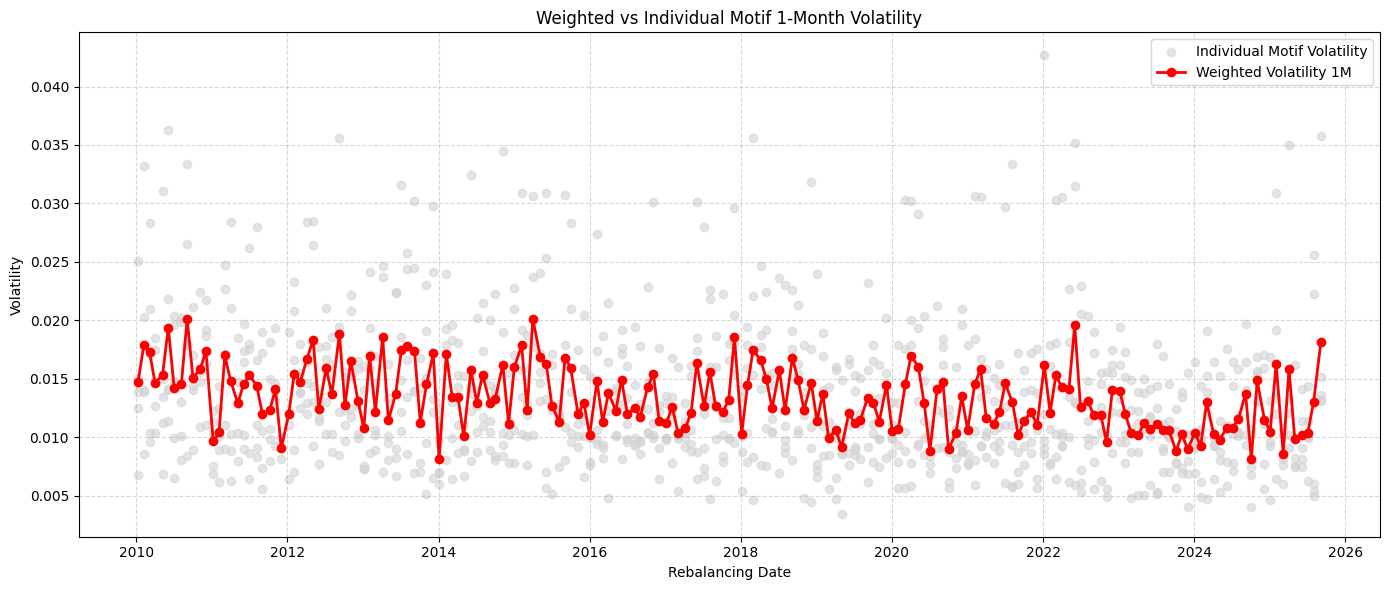

In [11]:
import matplotlib.pyplot as plt

# Ensure dates are datetime and sorted
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])
rebal_weighted_stats["RebalDate"] = pd.to_datetime(rebal_weighted_stats["RebalDate"])
top_regimes_df = top_regimes_df.sort_values("RebalDate")
rebal_weighted_stats = rebal_weighted_stats.sort_values("RebalDate")

plt.figure(figsize=(14, 6))

# Plot individual motif volatilities as semi-transparent points
plt.scatter(
    top_regimes_df["RebalDate"],
    top_regimes_df["Vol_1M"],
    color='lightgray',
    alpha=0.6,
    label="Individual Motif Volatility"
)

# Plot weighted volatility as solid line
plt.plot(
    rebal_weighted_stats["RebalDate"],
    rebal_weighted_stats["WgtVol_1M"],
    color='red',
    marker='o',
    linewidth=2,
    label="Weighted Volatility 1M"
)

plt.title("Weighted vs Individual Motif 1-Month Volatility")
plt.xlabel("Rebalancing Date")
plt.ylabel("Volatility")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
import numpy as np
import pandas as pd

def robust_nw_forecast(df, value_col, distance_col="dp", eta_factor=0.2):
    """
    Compute Nadaraya-Watson forecast with automatically scaled bandwidth.

    Parameters:
    - df: DataFrame with value_col (target) and distance_col (dp)
    - value_col: column to forecast (e.g., Vol_1M)
    - distance_col: column representing distance (smaller = closer)
    - eta_factor: fraction of mean distance to use as bandwidth (eta = mean(dp) * eta_factor)

    Returns:
    - Weighted forecast (float)
    """
    df = df[[value_col, distance_col]].dropna()
    if df.empty:
        return np.nan

    # Automatic bandwidth scaling
    mean_dp = df[distance_col].mean()
    eta = mean_dp * eta_factor
    if eta <= 0:
        eta = 1e-5  # safeguard

    # Gaussian kernel weights
    weights = np.exp(-(df[distance_col] ** 2) / (2 * eta**2))
    weights /= weights.sum()

    # Weighted forecast
    forecast = np.sum(weights * df[value_col])
    return forecast

# --- Compute NW forecast per rebal date ---
nw_forecasts = []

for rebal, group in top_regimes_df.groupby("RebalDate"):
    forecast = robust_nw_forecast(group, value_col="Vol_1M", distance_col="dp", eta_factor=0.2)
    nw_forecasts.append({"RebalDate": rebal, "NW_Vol_1M": forecast})

nw_forecast_df = pd.DataFrame(nw_forecasts).sort_values("RebalDate")

# Winsorize volatility metrics (1st and 99th percentiles)
for col in ["NW_Vol_1M"]:
    if col in nw_forecast_df.columns:
        nw_forecast_df[col] = winsorize_series(nw_forecast_df[col], lower=0.01, upper=0.01)

print(nw_forecast_df.head())


   RebalDate  NW_Vol_1M
0 2010-01-08   0.014715
1 2010-02-06   0.017819
2 2010-03-05   0.017896
3 2010-04-01   0.012751
4 2010-05-07   0.013017


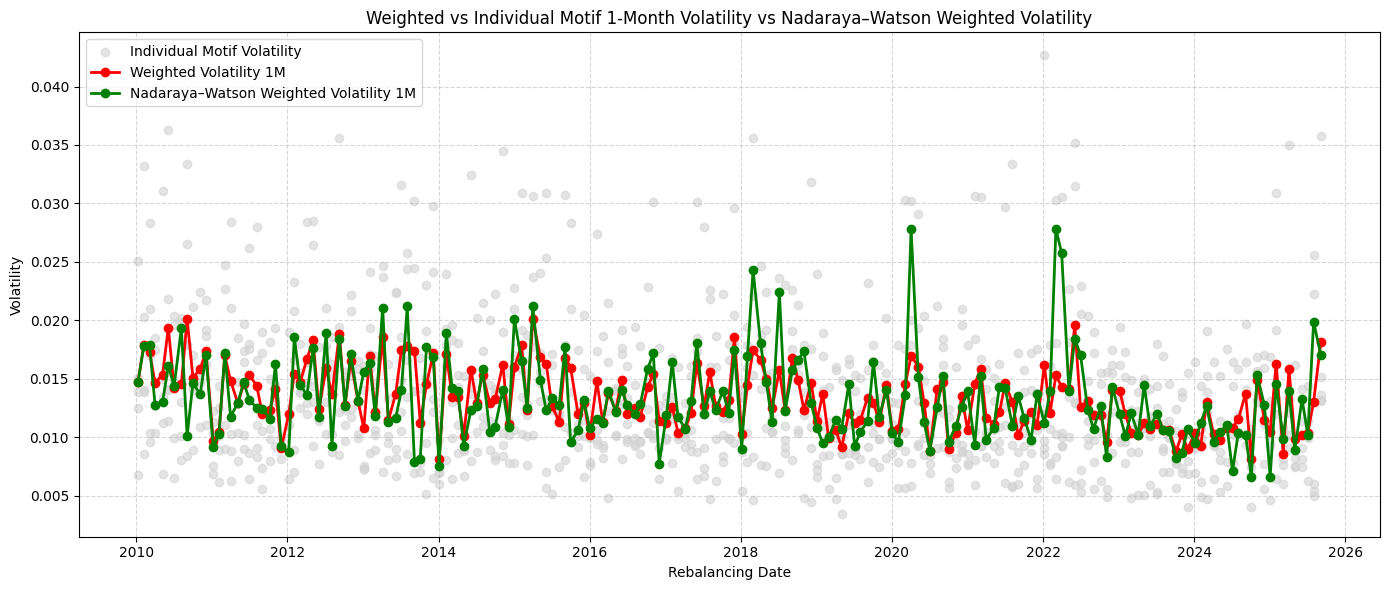

In [13]:
# Ensure dates are datetime and sorted
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])
rebal_weighted_stats["RebalDate"] = pd.to_datetime(rebal_weighted_stats["RebalDate"])
top_regimes_df = top_regimes_df.sort_values("RebalDate")
rebal_weighted_stats = rebal_weighted_stats.sort_values("RebalDate")

plt.figure(figsize=(14,6))

# Plot individual motif volatilities as semi-transparent points
plt.scatter(
    top_regimes_df["RebalDate"],
    top_regimes_df["Vol_1M"],
    color='lightgray',
    alpha=0.6,
    label="Individual Motif Volatility"
)

# Plot weighted volatility as solid line
plt.plot(
    rebal_weighted_stats["RebalDate"],
    rebal_weighted_stats["WgtVol_1M"],
    color='red',
    marker='o',
    linewidth=2,
    label="Weighted Volatility 1M"
)

plt.plot(
    nw_forecast_df["RebalDate"],
    nw_forecast_df["NW_Vol_1M"],
    color='green',
    marker='o',
    linewidth=2,
    label="Nadaraya–Watson Weighted Volatility 1M"
)

plt.title("Weighted vs Individual Motif 1-Month Volatility vs Nadaraya–Watson Weighted Volatility")
plt.xlabel("Rebalancing Date")
plt.xlabel("Rebalancing Date")
plt.ylabel("Volatility")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import numpy as np

# Function to compute realized 1-month volatility after a date
def realized_vol(df, date, window='1M', price_col=0):
    """
    df: price DataFrame (datetime index)
    date: reference date (datetime)
    window: pandas offset alias for 1 month ('1M')
    price_col: column index of prices
    """
    end_date = date + pd.DateOffset(months=1)
    mask = (df.index > date) & (df.index <= end_date)
    prices = df.loc[mask].iloc[:, price_col]
    if len(prices) < 2:
        return np.nan
    returns = prices.pct_change().dropna()
    return returns.std()  # daily volatility; multiply by sqrt(252) for annualized

# Ensure RebalDate column is datetime
nw_forecast_df["RebalDate"] = pd.to_datetime(nw_forecast_df["RebalDate"])
top_regimes_df["RebalDate"] = pd.to_datetime(top_regimes_df["RebalDate"])

# Compute observed volatility per rebal date
observed_vols = []
for date in nw_forecast_df["RebalDate"]:
    obs_vol = realized_vol(closeMergedDf, date, window='1M', price_col=0)
    observed_vols.append(obs_vol)

nw_forecast_df["Observed_Vol_1M"] = observed_vols

# Winsorize volatility metrics (1st and 99th percentiles)
for col in ["Observed_Vol_1M"]:
    if col in nw_forecast_df.columns:
        nw_forecast_df[col] = winsorize_series(nw_forecast_df[col], lower=0.01, upper=0.01)

# Inspect
print(nw_forecast_df.head())


   RebalDate  NW_Vol_1M  Observed_Vol_1M
0 2010-01-08   0.014715         0.012972
1 2010-02-06   0.017819         0.008696
2 2010-03-05   0.017896         0.006493
3 2010-04-01   0.012751         0.007737
4 2010-05-07   0.013017         0.015321


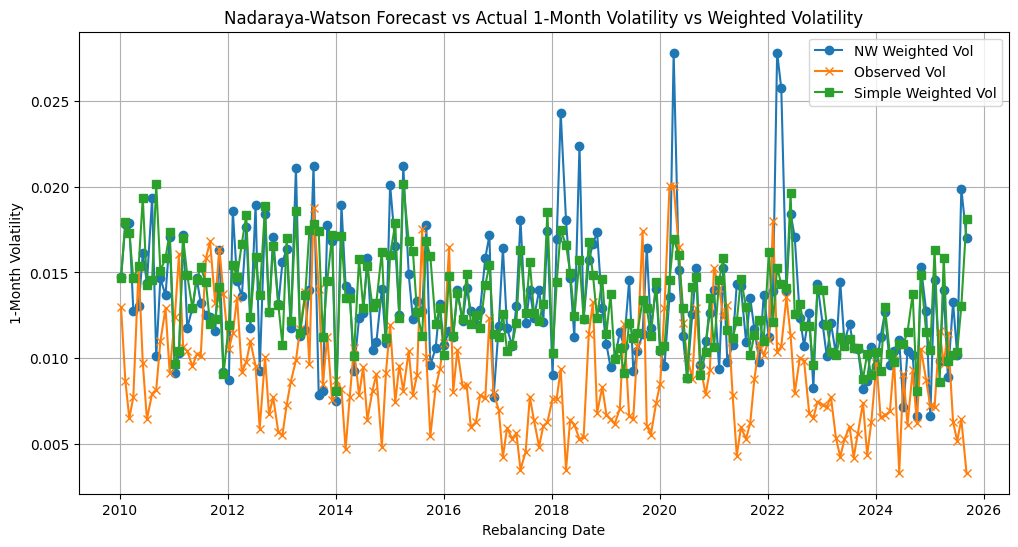

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["NW_Vol_1M"], marker='o', label="NW Weighted Vol")
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["Observed_Vol_1M"], marker='x', label="Observed Vol")
plt.plot(rebal_weighted_stats["RebalDate"],rebal_weighted_stats['WgtVol_1M'],marker='s', label="Simple Weighted Vol")

plt.xlabel("Rebalancing Date")
plt.ylabel("1-Month Volatility")
plt.title("Nadaraya-Watson Forecast vs Actual 1-Month Volatility vs Weighted Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
correlation_nw = nw_forecast_df["NW_Vol_1M"].corr(nw_forecast_df["Observed_Vol_1M"])
correlation = rebal_weighted_stats['WgtVol_1M'].corr(nw_forecast_df["Observed_Vol_1M"])
print(f"Correlation between simple forecast and actual volatility: {correlation:.4f}")
print(f"Correlation between NW forecast and actual volatility: {correlation_nw:.4f}")


Correlation between simple forecast and actual volatility: 0.1522
Correlation between NW forecast and actual volatility: 0.1119


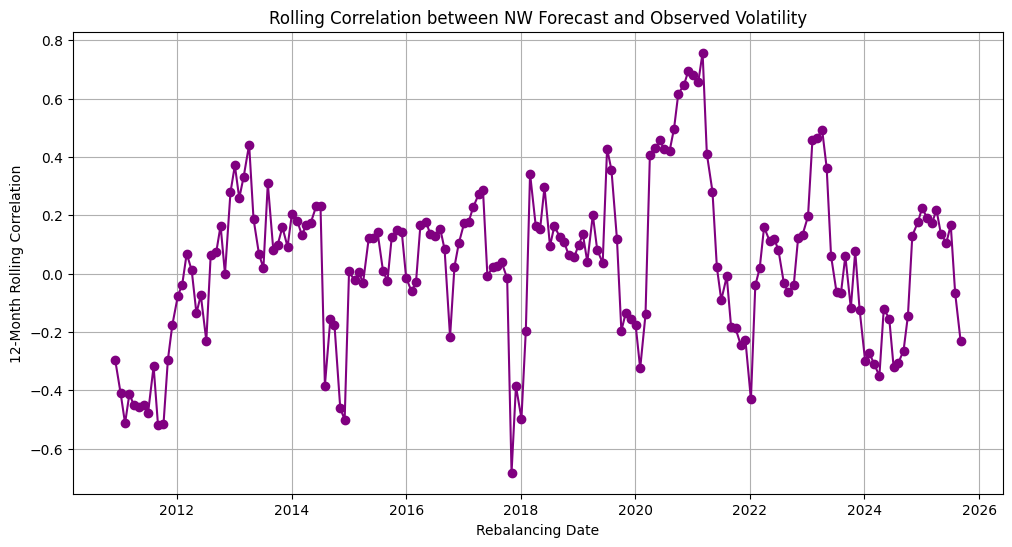

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure RebalDate is datetime and sorted
nw_forecast_df["RebalDate"] = pd.to_datetime(nw_forecast_df["RebalDate"])
nw_forecast_df = nw_forecast_df.sort_values("RebalDate").reset_index(drop=True)

# Set rolling window (e.g., 3 or 6 months)
rolling_window = 12  # 3-month rolling correlation

# Compute rolling correlation
nw_forecast_df["RollingCorr"] = nw_forecast_df["NW_Vol_1M"].rolling(rolling_window).corr(
    nw_forecast_df["Observed_Vol_1M"]
)

# Plot rolling correlation
plt.figure(figsize=(12, 6))
plt.plot(nw_forecast_df["RebalDate"], nw_forecast_df["RollingCorr"], marker='o', color='purple')
plt.xlabel("Rebalancing Date")
plt.ylabel(f"{rolling_window}-Month Rolling Correlation")
plt.title(f"Rolling Correlation between NW Forecast and Observed Volatility")
plt.grid(True)
plt.show()


In [18]:
# Get best matching motif (smallest dp) per rebal date
best_motif_df = top_regimes_df.loc[top_regimes_df.groupby("RebalDate")["dp"].idxmin()]

# Keep only relevant columns
best_motif_df = best_motif_df[["RebalDate", "Vol_1M", "dp"]].copy()
best_motif_df.rename(columns={"Vol_1M": "BestMotif_Vol_1M", "dp": "BestMotif_dp"}, inplace=True)
best_motif_df

,RebalDate,BestMotif_Vol_1M,BestMotif_dp
0,2010-01-08,0.015081,5.296594
5,2010-02-06,0.020274,5.758024
10,2010-03-05,0.020944,5.637041
15,2010-04-01,0.012661,4.063294
20,2010-05-07,0.013457,5.736204
...,...,...,...
907,2025-05-02,0.007504,4.487756
912,2025-06-06,0.014114,4.523627
917,2025-07-04,0.009910,2.446599
922,2025-08-01,0.022269,4.896723


In [19]:
# Merge on RebalDate
comparison_df = best_motif_df.merge(
    nw_forecast_df[["RebalDate", "Observed_Vol_1M"]],
    on="RebalDate",
    how="left"
)

# Inspect
print(comparison_df.head())


   RebalDate  BestMotif_Vol_1M  BestMotif_dp  Observed_Vol_1M
0 2010-01-08          0.015081      5.296594         0.012972
1 2010-02-06          0.020274      5.758024         0.008696
2 2010-03-05          0.020944      5.637041         0.006493
3 2010-04-01          0.012661      4.063294         0.007737
4 2010-05-07          0.013457      5.736204         0.015321


In [20]:
# Forecast error: best motif - observed
comparison_df["Error"] = comparison_df["BestMotif_Vol_1M"] - comparison_df["Observed_Vol_1M"]
comparison_df["AbsError"] = comparison_df["Error"].abs()

# Correlation
corr_best = comparison_df["BestMotif_Vol_1M"].corr(comparison_df["Observed_Vol_1M"])
print(f"Correlation between Best Motif Vol and Observed Vol: {corr_best:.4f}")


Correlation between Best Motif Vol and Observed Vol: 0.0625


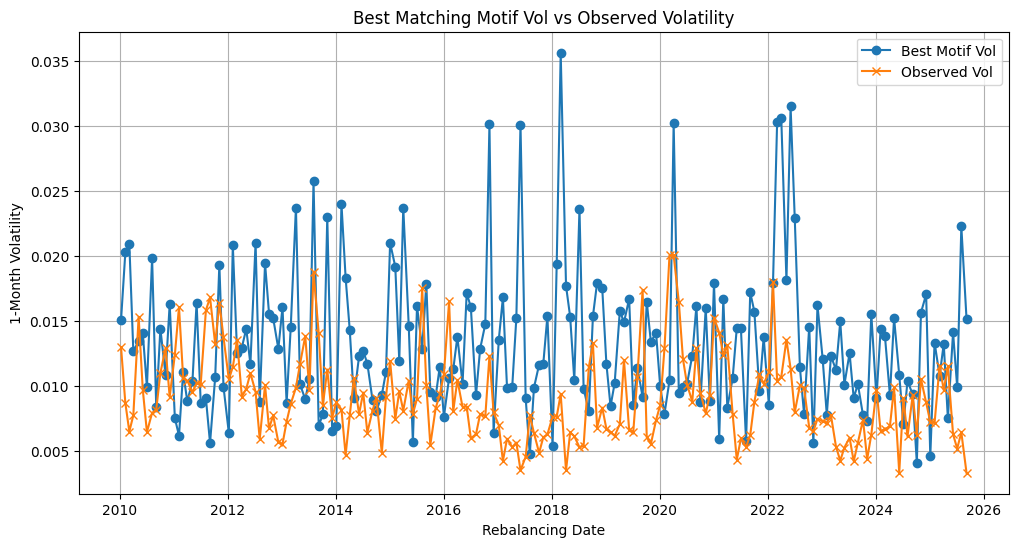

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(comparison_df["RebalDate"], comparison_df["BestMotif_Vol_1M"], marker='o', label="Best Motif Vol")
plt.plot(comparison_df["RebalDate"], comparison_df["Observed_Vol_1M"], marker='x', label="Observed Vol")
plt.xlabel("Rebalancing Date")
plt.ylabel("1-Month Volatility")
plt.title("Best Matching Motif Vol vs Observed Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
price_df = closeMergedDf.copy()
price_df['return'] = price_df['.NSEI'].pct_change()
price_df = price_df.dropna()

In [23]:
price_df['RealizedVol_1M'] =price_df['return'].rolling(window=30).std().dropna()
price_df = price_df.dropna()

In [24]:
# --- Define weekly rebalancing period: Jan 2020 → last available trading day ---
start_date = price_df.index.min()
end_date = price_df.index.max()  # last available date from your price data

# Filter rebal dates within the window
monthly_rebal_df = rebal_df.loc[
    (rebal_df['Date'] >= start_date) & (rebal_df['Date'] <= end_date)
]

# Keep first rebal date per month
monthly_rebal_df = (
    monthly_rebal_df.loc[
        monthly_rebal_df.groupby(monthly_rebal_df['Date'].dt.to_period('M'))['Date'].idxmin()
    ]
    .reset_index(drop=True)
)

# Convert to list
monthly_rebal_dates = monthly_rebal_df['Date'].tolist()

print(f"Total monthly rebal dates: {len(monthly_rebal_dates)}")
print("First 5:", monthly_rebal_dates[:5])
print("Last 5:", monthly_rebal_dates[-5:])


Total monthly rebal dates: 358
First 5: [Timestamp('1995-12-15 00:00:00'), Timestamp('1996-01-05 00:00:00'), Timestamp('1996-02-02 00:00:00'), Timestamp('1996-03-01 00:00:00'), Timestamp('1996-04-04 00:00:00')]
Last 5: [Timestamp('2025-05-02 00:00:00'), Timestamp('2025-06-06 00:00:00'), Timestamp('2025-07-04 00:00:00'), Timestamp('2025-08-01 00:00:00'), Timestamp('2025-09-05 00:00:00')]


In [25]:
observed_vols_df = pd.DataFrame(index=monthly_rebal_dates)
observed_vols_df

""
1995-12-15
1996-01-05
1996-02-02
1996-03-01
1996-04-04
...
2025-05-02
2025-06-06
2025-07-04
2025-08-01


In [26]:
# Compute observed volatility per weekly rebal date
observed_vols = []
for date in monthly_rebal_dates:
    obs_vol = realized_vol(price_df, date, window='1M', price_col=0)
    observed_vols.append(obs_vol)

observed_vols_df["Observed_Vol_1M"] = observed_vols
observed_vols_df = observed_vols_df.dropna()

# Inspect
print(observed_vols_df.head())

            Observed_Vol_1M
1995-12-15         0.008925
1996-01-05         0.018031
1996-02-02         0.023587
1996-03-01         0.013133
1996-04-04         0.017627


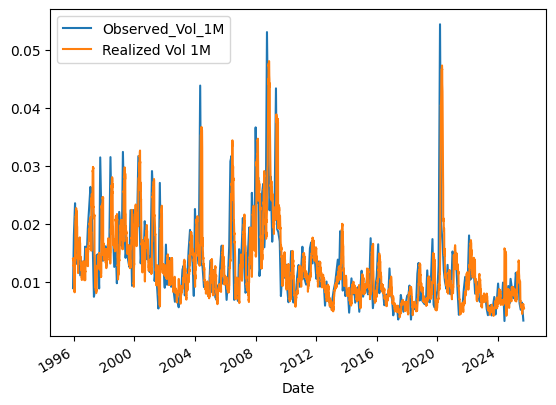

In [27]:
observed_vols_df.plot()
price_df['RealizedVol_1M'].plot(label='Realized Vol 1M')
plt.legend()

In [28]:
rebal_weighted_stats['Observed_Vol_1M'] = nw_forecast_df['Observed_Vol_1M']
rebal_weighted_stats = rebal_weighted_stats.dropna()
rebal_weighted_stats

,RebalDate,WgtVol_1M,WgtMeanRet_1M,WgtRealizedVol_1M,WgtSkew_1M,WgtKurt_1M,Observed_Vol_1M
0,2010-01-08,0.014687,0.003401,0.004804,-0.081864,-0.032778,0.012972
1,2010-02-06,0.017916,0.001714,0.008004,0.268353,-0.322796,0.008696
2,2010-03-05,0.017297,0.000769,0.006576,0.347760,-0.311535,0.006493
3,2010-04-01,0.014648,0.002315,0.004428,0.155311,-0.659711,0.007737
4,2010-05-07,0.015360,0.001410,0.005304,-0.141396,0.417394,0.015321
...,...,...,...,...,...,...,...
184,2025-05-02,0.009818,0.001069,0.002141,-0.206195,0.326644,0.011497
185,2025-06-06,0.010160,0.000990,0.002019,-0.298245,0.009285,0.006287
186,2025-07-04,0.010381,0.000635,0.002369,-0.105643,-0.037927,0.005184
187,2025-08-01,0.013046,0.001100,0.005188,0.556880,0.497872,0.006430


In [29]:
# Winsorize volatility metrics (1st and 99th percentiles)
for col in ["Observed_Vol_1M", "WgtVol_1M"]:
    if col in rebal_weighted_stats.columns:
        rebal_weighted_stats[col] = winsorize_series(rebal_weighted_stats[col], lower=0.01, upper=0.01)

In [30]:
n_buckets = 15

# Prepare columns for buckets
nw_forecast_df["VolBucket"] = np.nan
rebal_weighted_stats["VolBucket"] = np.nan
rebal_weighted_stats["Observed_VolBucket"] = np.nan

# Loop over each rebal date
for idx, date in enumerate(rebal_weighted_stats["RebalDate"]):
    # Past-only observed vols up to this date
    past_obs_vols = observed_vols_df.loc[observed_vols_df.index <= date, "Observed_Vol_1M"]

    if len(past_obs_vols) < n_buckets:
        # Skip or assign NaN if not enough data
        continue

    # Compute bucket edges from past-only data
    bucket_edges = np.quantile(past_obs_vols, np.linspace(0, 1, n_buckets + 1))

    # Assign current predicted/weighted vol to bucket
    wgt_vol = rebal_weighted_stats.at[idx, "WgtVol_1M"]
    obs_vol = rebal_weighted_stats.at[idx, "Observed_Vol_1M"]
    nw_vol = nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date, "NW_Vol_1M"].values[0]


    def assign_bucket(vol, edges):
        for i in range(len(edges) - 1):
            if edges[i] <= vol < edges[i + 1]:
                return i + 1
        if vol >= edges[-1]:
            return len(edges) - 1
        return np.nan


    rebal_weighted_stats.at[idx, "VolBucket"] = assign_bucket(wgt_vol, bucket_edges)
    rebal_weighted_stats.at[idx, "Observed_VolBucket"] = assign_bucket(obs_vol, bucket_edges)
    nw_forecast_df.loc[nw_forecast_df["RebalDate"] == date, "VolBucket"] = assign_bucket(nw_vol, bucket_edges)

# Now each date's bucket assignment only depends on past data → no forward bias


In [31]:
rebal_weighted_stats

,RebalDate,WgtVol_1M,WgtMeanRet_1M,WgtRealizedVol_1M,WgtSkew_1M,WgtKurt_1M,Observed_Vol_1M,VolBucket,Observed_VolBucket
0,2010-01-08,0.014687,0.003401,0.004804,-0.081864,-0.032778,0.012972,9.0,7.0
1,2010-02-06,0.017916,0.001714,0.008004,0.268353,-0.322796,0.008696,11.0,2.0
2,2010-03-05,0.017297,0.000769,0.006576,0.347760,-0.311535,0.006493,11.0,1.0
3,2010-04-01,0.014648,0.002315,0.004428,0.155311,-0.659711,0.007737,9.0,2.0
4,2010-05-07,0.015360,0.001410,0.005304,-0.141396,0.417394,0.015321,9.0,9.0
...,...,...,...,...,...,...,...,...,...
184,2025-05-02,0.009818,0.001069,0.002141,-0.206195,0.326644,0.011497,7.0,9.0
185,2025-06-06,0.010160,0.000990,0.002019,-0.298245,0.009285,0.006287,8.0,2.0
186,2025-07-04,0.010381,0.000635,0.002369,-0.105643,-0.037927,0.005184,8.0,1.0
187,2025-08-01,0.013046,0.001100,0.005188,0.556880,0.497872,0.006430,11.0,2.0


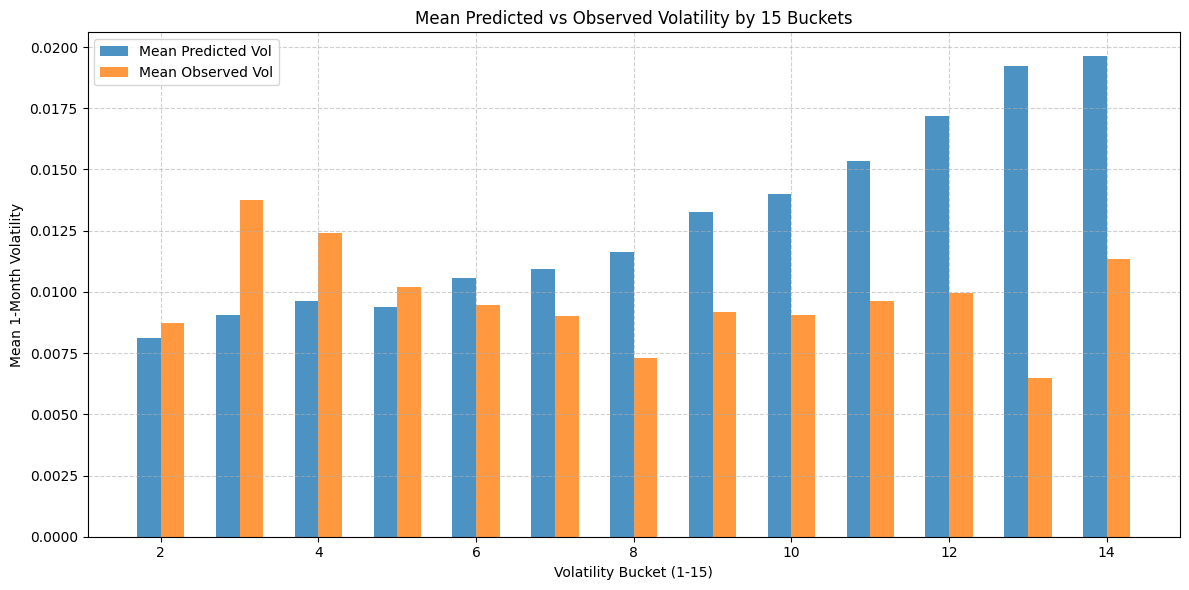

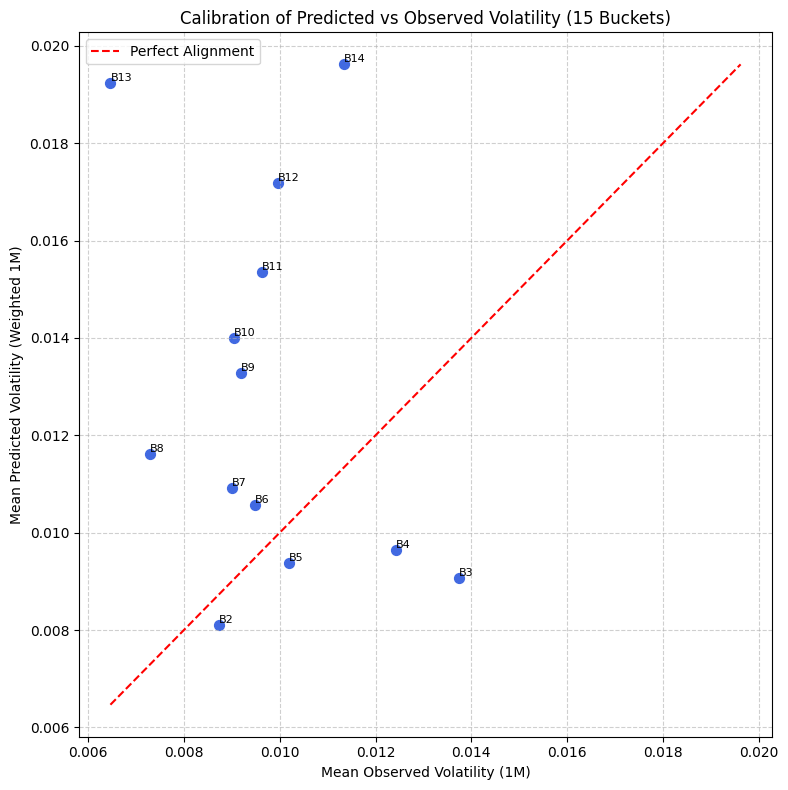

In [32]:
# --- Compute mean per bucket ---
plot_df = rebal_weighted_stats.dropna(subset=["Observed_Vol_1M", "VolBucket"]).copy()
bucket_means = (
    plot_df.groupby("VolBucket")[["WgtVol_1M", "Observed_Vol_1M"]]
    .mean()
    .reset_index()
)

# --- Plot mean predicted vs observed for 30 buckets ---
plt.figure(figsize=(12,6))
bar_width = 0.3
x = bucket_means["VolBucket"]

plt.bar(x - bar_width/2, bucket_means["WgtVol_1M"], width=bar_width, label="Mean Predicted Vol", alpha=0.8)
plt.bar(x + bar_width/2, bucket_means["Observed_Vol_1M"], width=bar_width, label="Mean Observed Vol", alpha=0.8)

plt.xlabel(f"Volatility Bucket (1-{n_buckets})")
plt.ylabel("Mean 1-Month Volatility")
plt.title(f"Mean Predicted vs Observed Volatility by {n_buckets} Buckets")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Optional scatter with bucket labels
plt.figure(figsize=(8,8))
plt.scatter(bucket_means["Observed_Vol_1M"], bucket_means["WgtVol_1M"], color='royalblue', s=50)
lims = [
    min(bucket_means["Observed_Vol_1M"].min(), bucket_means["WgtVol_1M"].min()),
    max(bucket_means["Observed_Vol_1M"].max(), bucket_means["WgtVol_1M"].max())
]
plt.plot(lims, lims, 'r--', label="Perfect Alignment")
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')
plt.xlabel("Mean Observed Volatility (1M)")
plt.ylabel("Mean Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

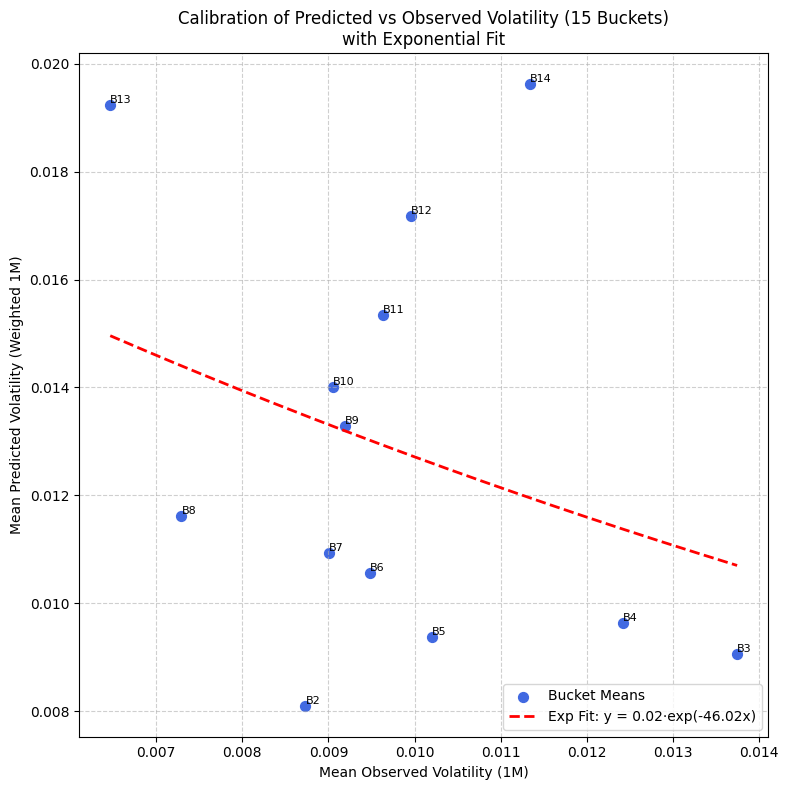

In [33]:
from scipy.optimize import curve_fit
import numpy as np

# --- Define exponential function ---
def exp_func(x, a, b):
    return a * np.exp(b * x)

# Extract x/y data
xdata = bucket_means["Observed_Vol_1M"].values
ydata = bucket_means["WgtVol_1M"].values

# --- Fit exponential curve ---
popt, _ = curve_fit(exp_func, xdata, ydata, p0=(1, 0.1))  # initial guess

# Generate smooth fitted curve
x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, *popt)

# --- Plot scatter + exponential fit ---
plt.figure(figsize=(8, 8))
plt.scatter(xdata, ydata, color='royalblue', s=50, label='Bucket Means')

# Add exponential fit curve
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {popt[0]:.2f}·exp({popt[1]:.2f}x)")

# Annotate buckets
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')

plt.xlabel("Mean Observed Volatility (1M)")
plt.ylabel("Mean Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)\nwith Exponential Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


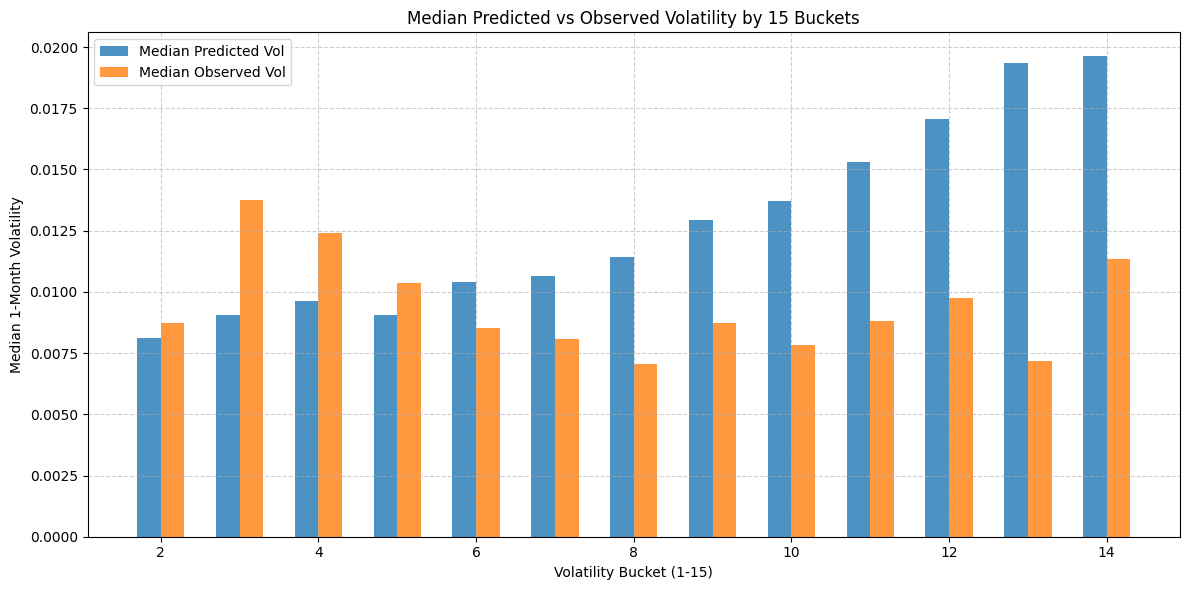

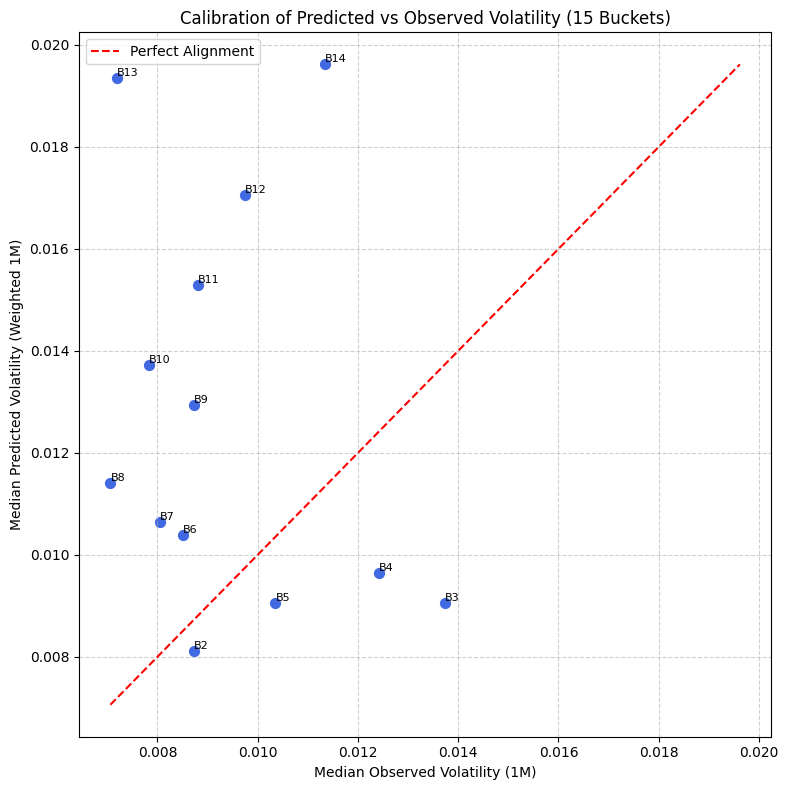

In [34]:
# --- Compute mean per bucket ---
plot_df = rebal_weighted_stats.dropna(subset=["Observed_Vol_1M", "VolBucket"]).copy()
bucket_means = (
    plot_df.groupby("VolBucket")[["WgtVol_1M", "Observed_Vol_1M"]]
    .median()
    .reset_index()
)

# --- Plot mean predicted vs observed for 30 buckets ---
plt.figure(figsize=(12,6))
bar_width = 0.3
x = bucket_means["VolBucket"]

plt.bar(x - bar_width/2, bucket_means["WgtVol_1M"], width=bar_width, label="Median Predicted Vol", alpha=0.8)
plt.bar(x + bar_width/2, bucket_means["Observed_Vol_1M"], width=bar_width, label="Median Observed Vol", alpha=0.8)

plt.xlabel(f"Volatility Bucket (1-{n_buckets})")
plt.ylabel("Median 1-Month Volatility")
plt.title(f"Median Predicted vs Observed Volatility by {n_buckets} Buckets")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Optional scatter with bucket labels
plt.figure(figsize=(8,8))
plt.scatter(bucket_means["Observed_Vol_1M"], bucket_means["WgtVol_1M"], color='royalblue', s=50)
lims = [
    min(bucket_means["Observed_Vol_1M"].min(), bucket_means["WgtVol_1M"].min()),
    max(bucket_means["Observed_Vol_1M"].max(), bucket_means["WgtVol_1M"].max())
]
plt.plot(lims, lims, 'r--', label="Perfect Alignment")
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')
plt.xlabel("Median Observed Volatility (1M)")
plt.ylabel("Median Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

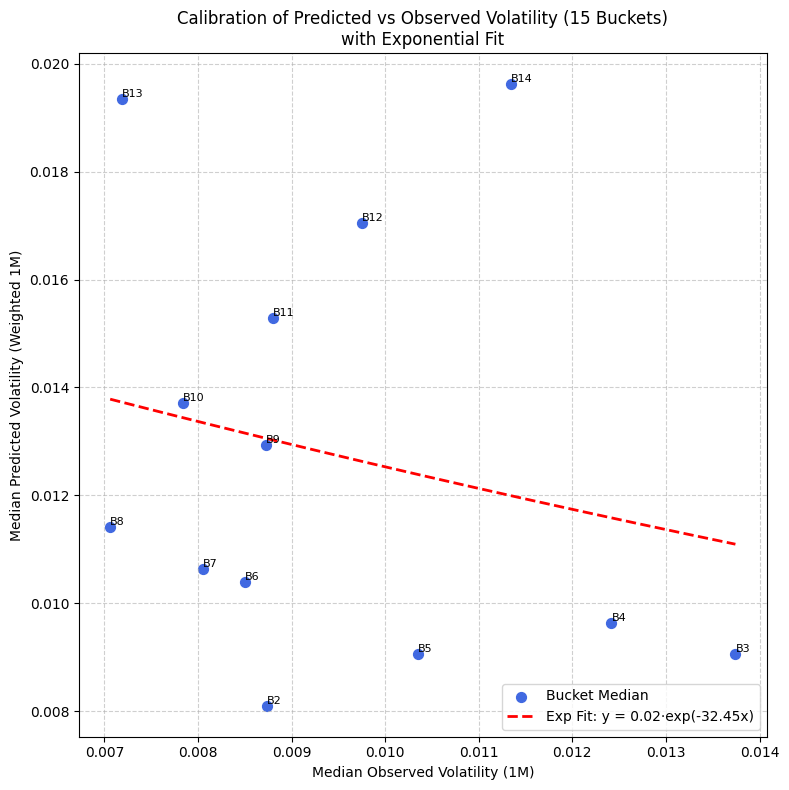

In [35]:
from scipy.optimize import curve_fit
import numpy as np

# --- Define exponential function ---
def exp_func(x, a, b):
    return a * np.exp(b * x)

# Extract x/y data
xdata = bucket_means["Observed_Vol_1M"].values
ydata = bucket_means["WgtVol_1M"].values

# --- Fit exponential curve ---
popt, _ = curve_fit(exp_func, xdata, ydata, p0=(1, 0.1))  # initial guess

# Generate smooth fitted curve
x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, *popt)

# --- Plot scatter + exponential fit ---
plt.figure(figsize=(8, 8))
plt.scatter(xdata, ydata, color='royalblue', s=50, label='Bucket Median')

# Add exponential fit curve
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {popt[0]:.2f}·exp({popt[1]:.2f}x)")

# Annotate buckets
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')

plt.xlabel("Median Observed Volatility (1M)")
plt.ylabel("Median Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)\nwith Exponential Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


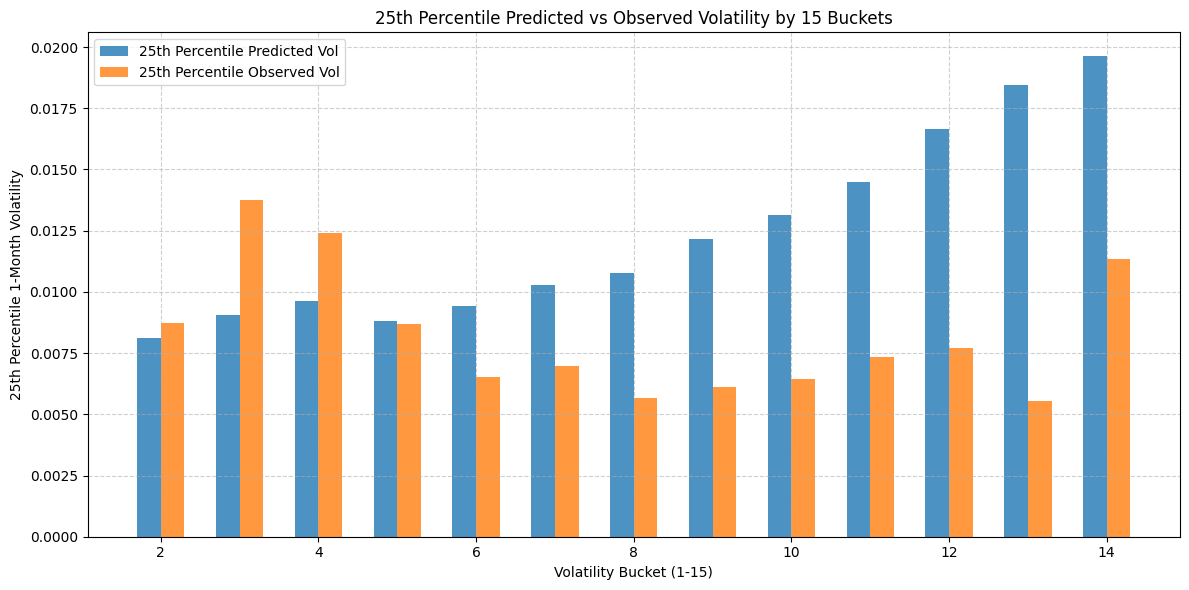

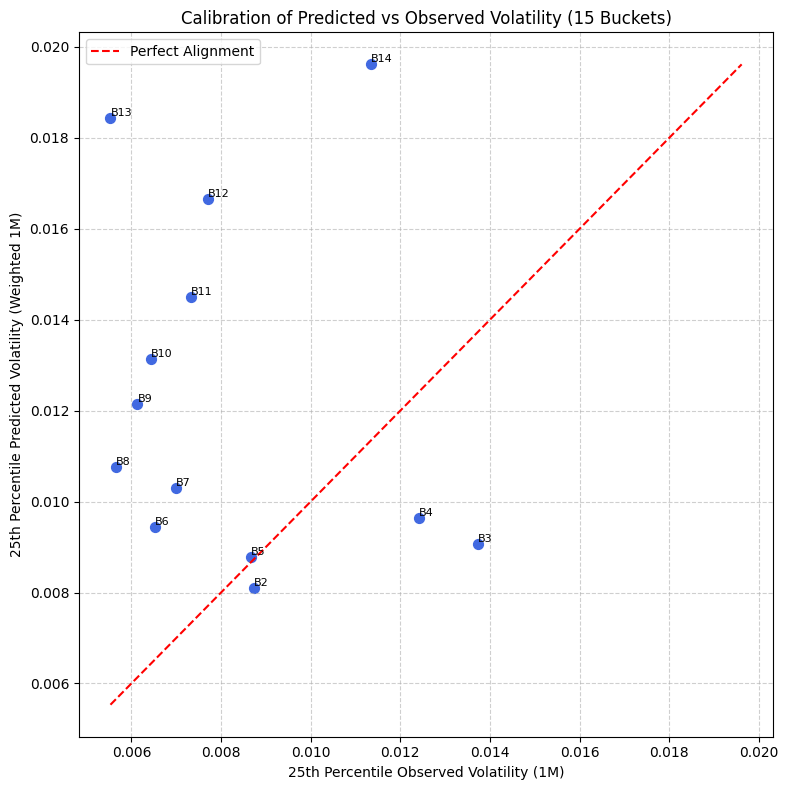

In [36]:
# --- Compute mean per bucket ---
plot_df = rebal_weighted_stats.dropna(subset=["Observed_Vol_1M", "VolBucket"]).copy()
bucket_means = (
    plot_df.groupby("VolBucket")[["WgtVol_1M", "Observed_Vol_1M"]]
    .quantile(0.25)
    .reset_index()
)

# --- Plot mean predicted vs observed for 30 buckets ---
plt.figure(figsize=(12,6))
bar_width = 0.3
x = bucket_means["VolBucket"]

plt.bar(x - bar_width/2, bucket_means["WgtVol_1M"], width=bar_width, label="25th Percentile Predicted Vol", alpha=0.8)
plt.bar(x + bar_width/2, bucket_means["Observed_Vol_1M"], width=bar_width, label="25th Percentile Observed Vol", alpha=0.8)

plt.xlabel(f"Volatility Bucket (1-{n_buckets})")
plt.ylabel("25th Percentile 1-Month Volatility")
plt.title(f"25th Percentile Predicted vs Observed Volatility by {n_buckets} Buckets")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Optional scatter with bucket labels
plt.figure(figsize=(8,8))
plt.scatter(bucket_means["Observed_Vol_1M"], bucket_means["WgtVol_1M"], color='royalblue', s=50)
lims = [
    min(bucket_means["Observed_Vol_1M"].min(), bucket_means["WgtVol_1M"].min()),
    max(bucket_means["Observed_Vol_1M"].max(), bucket_means["WgtVol_1M"].max())
]
plt.plot(lims, lims, 'r--', label="Perfect Alignment")
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')
plt.xlabel("25th Percentile Observed Volatility (1M)")
plt.ylabel("25th Percentile Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

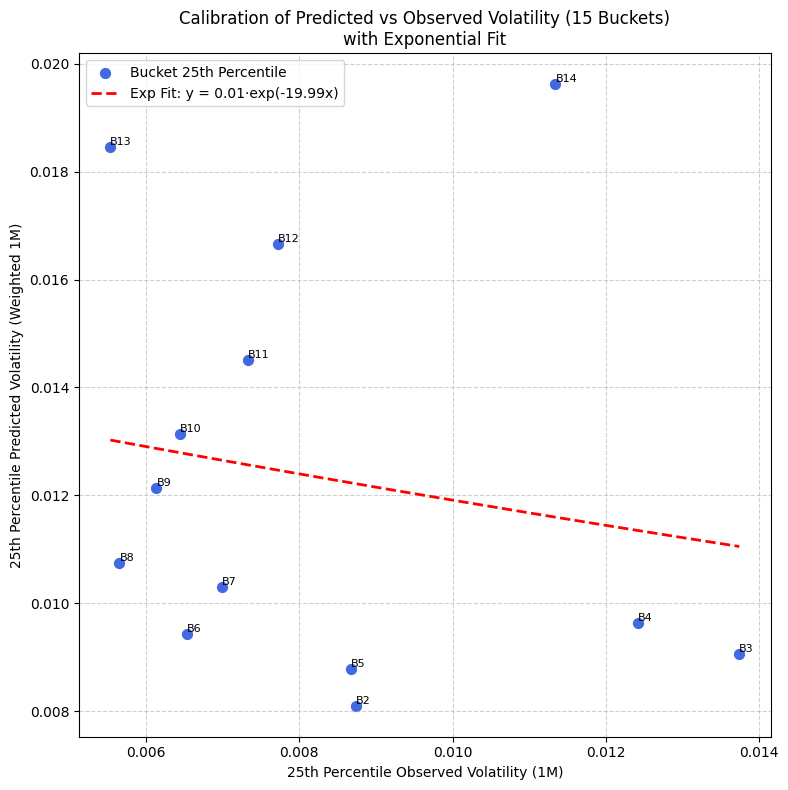

In [37]:
from scipy.optimize import curve_fit
import numpy as np

# --- Define exponential function ---
def exp_func(x, a, b):
    return a * np.exp(b * x)

# Extract x/y data
xdata = bucket_means["Observed_Vol_1M"].values
ydata = bucket_means["WgtVol_1M"].values

# --- Fit exponential curve ---
popt, _ = curve_fit(exp_func, xdata, ydata, p0=(1, 0.1))  # initial guess

# Generate smooth fitted curve
x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, *popt)

# --- Plot scatter + exponential fit ---
plt.figure(figsize=(8, 8))
plt.scatter(xdata, ydata, color='royalblue', s=50, label='Bucket 25th Percentile')

# Add exponential fit curve
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {popt[0]:.2f}·exp({popt[1]:.2f}x)")

# Annotate buckets
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')

plt.xlabel("25th Percentile Observed Volatility (1M)")
plt.ylabel("25th Percentile Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)\nwith Exponential Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


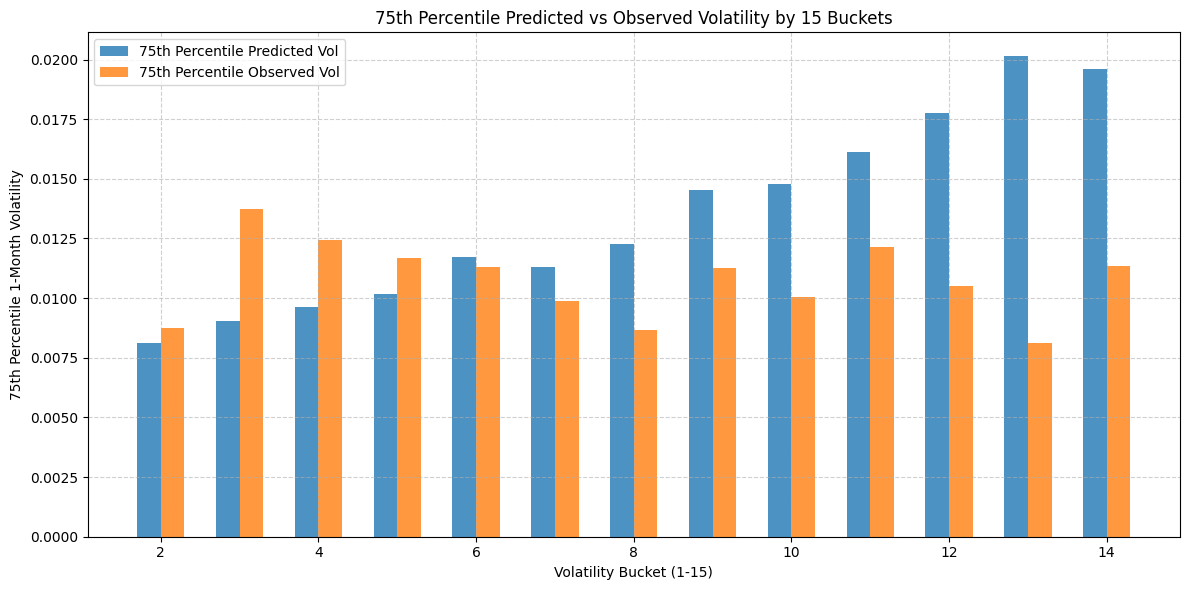

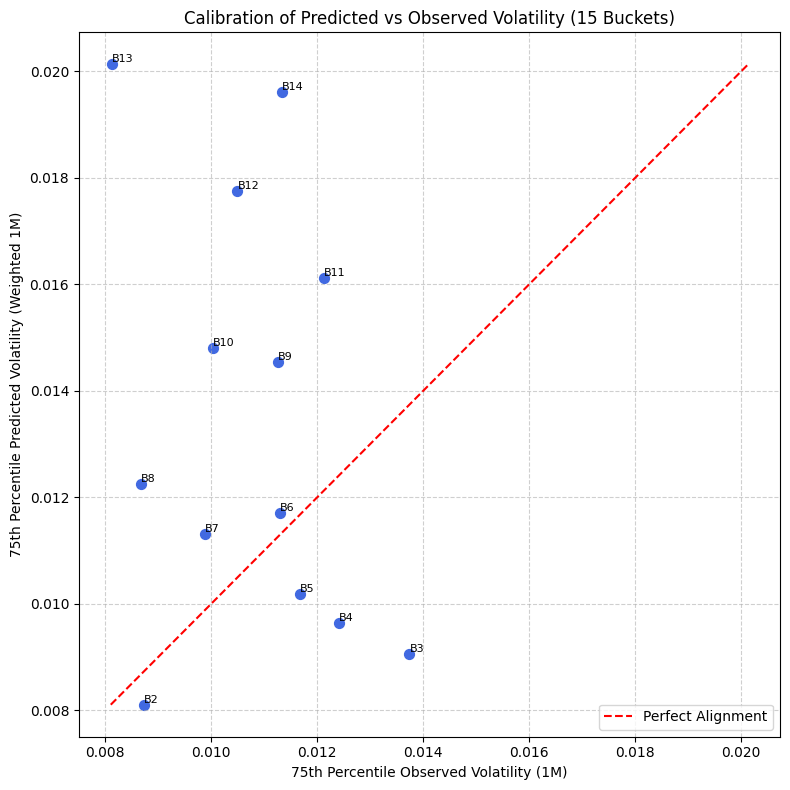

In [38]:
# --- Compute mean per bucket ---
plot_df = rebal_weighted_stats.dropna(subset=["Observed_Vol_1M", "VolBucket"]).copy()
bucket_means = (
    plot_df.groupby("VolBucket")[["WgtVol_1M", "Observed_Vol_1M"]]
    .quantile(0.75)
    .reset_index()
)

# --- Plot mean predicted vs observed for 30 buckets ---
plt.figure(figsize=(12,6))
bar_width = 0.3
x = bucket_means["VolBucket"]

plt.bar(x - bar_width/2, bucket_means["WgtVol_1M"], width=bar_width, label="75th Percentile Predicted Vol", alpha=0.8)
plt.bar(x + bar_width/2, bucket_means["Observed_Vol_1M"], width=bar_width, label="75th Percentile Observed Vol", alpha=0.8)

plt.xlabel(f"Volatility Bucket (1-{n_buckets})")
plt.ylabel("75th Percentile 1-Month Volatility")
plt.title(f"75th Percentile Predicted vs Observed Volatility by {n_buckets} Buckets")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Optional scatter with bucket labels
plt.figure(figsize=(8,8))
plt.scatter(bucket_means["Observed_Vol_1M"], bucket_means["WgtVol_1M"], color='royalblue', s=50)
lims = [
    min(bucket_means["Observed_Vol_1M"].min(), bucket_means["WgtVol_1M"].min()),
    max(bucket_means["Observed_Vol_1M"].max(), bucket_means["WgtVol_1M"].max())
]
plt.plot(lims, lims, 'r--', label="Perfect Alignment")
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')
plt.xlabel("75th Percentile Observed Volatility (1M)")
plt.ylabel("75th Percentile Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

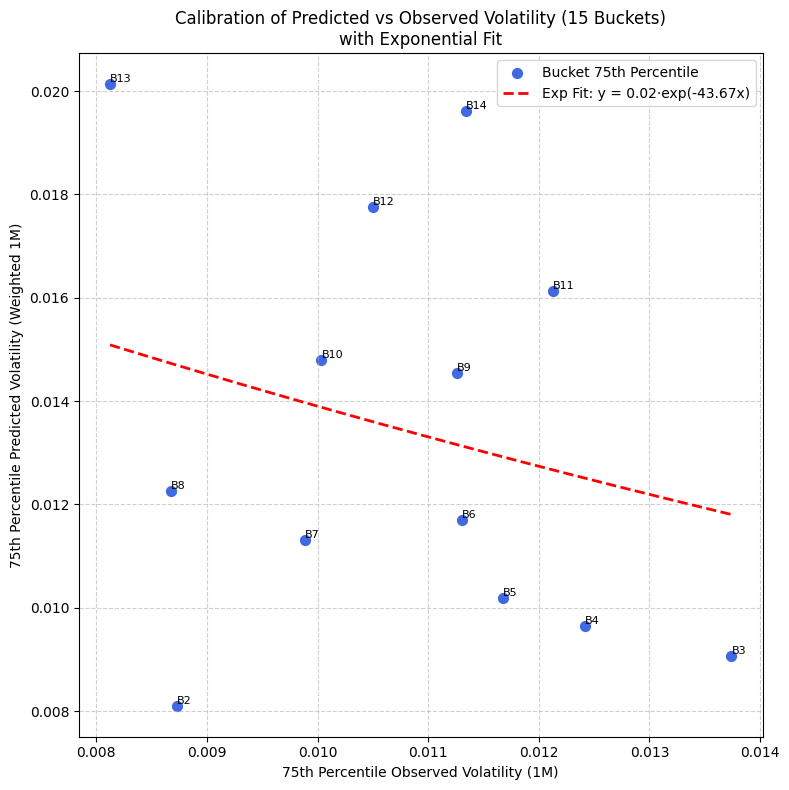

In [39]:
from scipy.optimize import curve_fit
import numpy as np

# --- Define exponential function ---
def exp_func(x, a, b):
    return a * np.exp(b * x)

# Extract x/y data
xdata = bucket_means["Observed_Vol_1M"].values
ydata = bucket_means["WgtVol_1M"].values

# --- Fit exponential curve ---
popt, _ = curve_fit(exp_func, xdata, ydata, p0=(1, 0.1))  # initial guess

# Generate smooth fitted curve
x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, *popt)

# --- Plot scatter + exponential fit ---
plt.figure(figsize=(8, 8))
plt.scatter(xdata, ydata, color='royalblue', s=50, label='Bucket 75th Percentile')

# Add exponential fit curve
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {popt[0]:.2f}·exp({popt[1]:.2f}x)")

# Annotate buckets
for i, row in bucket_means.iterrows():
    plt.text(row["Observed_Vol_1M"], row["WgtVol_1M"], f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')

plt.xlabel("75th Percentile Observed Volatility (1M)")
plt.ylabel("75th Percentile Predicted Volatility (Weighted 1M)")
plt.title(f"Calibration of Predicted vs Observed Volatility ({n_buckets} Buckets)\nwith Exponential Fit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [40]:
# --- Compute summary statistics per volatility bucket ---
plot_df = rebal_weighted_stats.dropna(subset=["Observed_Vol_1M", "VolBucket"]).copy()

bucket_stats = (
    plot_df.groupby("VolBucket")[["WgtVol_1M", "Observed_Vol_1M"]]
    .agg([
        "mean",
        "median",
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        "count"
    ])
)

# --- Clean column names properly ---
rename_map = {
    "mean": "mean",
    "median": "median",
    "<lambda_0>": "p25",
    "<lambda_1>": "p75",
    "count": "count"
}

bucket_stats.columns = [
    f"{col[0]}_{rename_map[col[1]]}" for col in bucket_stats.columns
]

bucket_stats = bucket_stats.reset_index()
print(bucket_stats.head())


   VolBucket  WgtVol_1M_mean  WgtVol_1M_median  WgtVol_1M_p25  WgtVol_1M_p75  \
0        2.0        0.008106          0.008106       0.008106       0.008106   
1        3.0        0.009061          0.009061       0.009061       0.009061   
2        4.0        0.009640          0.009640       0.009640       0.009640   
3        5.0        0.009372          0.009064       0.008791       0.010187   
4        6.0        0.010564          0.010397       0.009435       0.011706   

   WgtVol_1M_count  Observed_Vol_1M_mean  Observed_Vol_1M_median  \
0                1              0.008733                0.008733   
1                1              0.013742                0.013742   
2                1              0.012417                0.012417   
3                8              0.010200                0.010353   
4               11              0.009481                0.008504   

   Observed_Vol_1M_p25  Observed_Vol_1M_p75  Observed_Vol_1M_count  
0             0.008733             0.0087

In [41]:
bucket_stats

,VolBucket,WgtVol_1M_mean,WgtVol_1M_median,WgtVol_1M_p25,WgtVol_1M_p75,WgtVol_1M_count,Observed_Vol_1M_mean,Observed_Vol_1M_median,Observed_Vol_1M_p25,Observed_Vol_1M_p75,Observed_Vol_1M_count
0,2.0,0.008106,0.008106,0.008106,0.008106,1,0.008733,0.008733,0.008733,0.008733,1
1,3.0,0.009061,0.009061,0.009061,0.009061,1,0.013742,0.013742,0.013742,0.013742,1
2,4.0,0.009640,0.009640,0.009640,0.009640,1,0.012417,0.012417,0.012417,0.012417,1
3,5.0,0.009372,0.009064,0.008791,0.010187,8,0.010200,0.010353,0.008670,0.011676,8
4,6.0,0.010564,0.010397,0.009435,0.011706,11,0.009481,0.008504,0.006527,0.011302,11
5,7.0,0.010927,0.010636,0.010295,0.011318,21,0.009001,0.008055,0.006984,0.009887,21
6,8.0,0.011621,0.011409,0.010755,0.012253,34,0.007294,0.007062,0.005651,0.008674,34
7,9.0,0.013282,0.012940,0.012144,0.014545,37,0.009189,0.008729,0.006134,0.011264,37
8,10.0,0.014003,0.013720,0.013142,0.014799,17,0.009049,0.007839,0.006436,0.010036,17
9,11.0,0.015352,0.015288,0.014500,0.016123,31,0.009631,0.008803,0.007325,0.012126,31


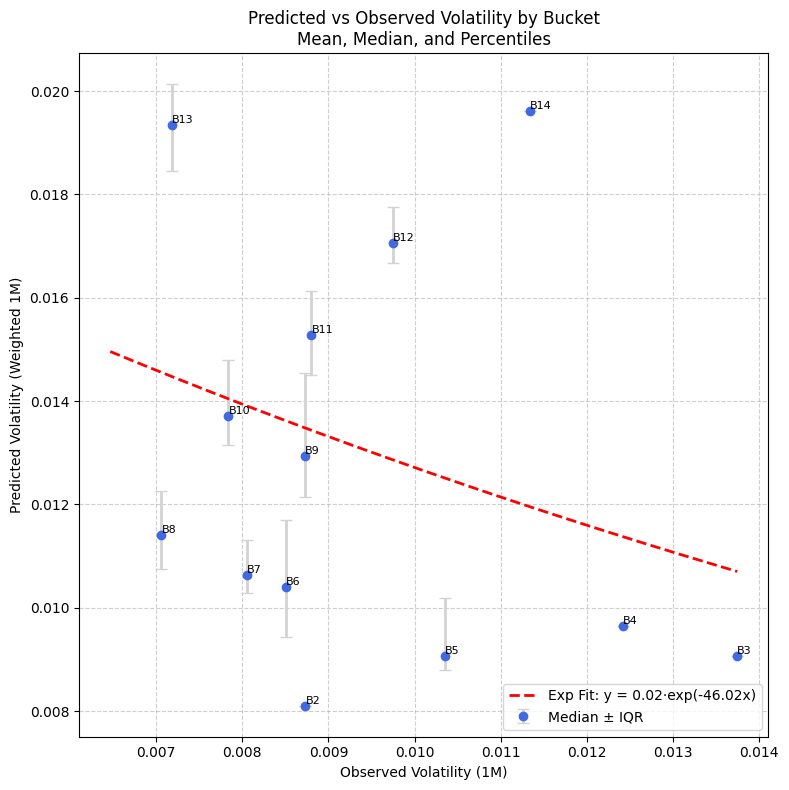

In [42]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

# --- Define exponential function ---
def exp_func(x, a, b):
    return a * np.exp(b * x)

# --- Prepare data ---
xdata = bucket_stats["Observed_Vol_1M_mean"].values  # x-axis (Observed Vol)
ydata = bucket_stats["WgtVol_1M_mean"].values        # y-axis (Predicted Vol)

# --- Fit exponential curve (optional) ---
popt, _ = curve_fit(exp_func, xdata, ydata, p0=(1, 0.1))

# Generate smooth curve
x_fit = np.linspace(xdata.min(), xdata.max(), 200)
y_fit = exp_func(x_fit, *popt)

# --- Plot setup ---
plt.figure(figsize=(8, 8))

# Add percentile range as vertical error bars
plt.errorbar(
    bucket_stats["Observed_Vol_1M_median"],
    bucket_stats["WgtVol_1M_median"],
    yerr=[
        bucket_stats["WgtVol_1M_median"] - bucket_stats["WgtVol_1M_p25"],
        bucket_stats["WgtVol_1M_p75"] - bucket_stats["WgtVol_1M_median"]
    ],
    fmt='o',
    color='royalblue',
    ecolor='lightgray',
    elinewidth=2,
    capsize=4,
    label='Median ± IQR'
)

# Add exponential fit curve
plt.plot(x_fit, y_fit, 'r--', linewidth=2,
         label=f"Exp Fit: y = {popt[0]:.2f}·exp({popt[1]:.2f}x)")

# Annotate bucket numbers
for i, row in bucket_stats.iterrows():
    plt.text(row["Observed_Vol_1M_median"], row["WgtVol_1M_median"],
             f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')

# --- Aesthetic setup ---
plt.xlabel("Observed Volatility (1M)")
plt.ylabel("Predicted Volatility (Weighted 1M)")
plt.title("Predicted vs Observed Volatility by Bucket\nMean, Median, and Percentiles")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


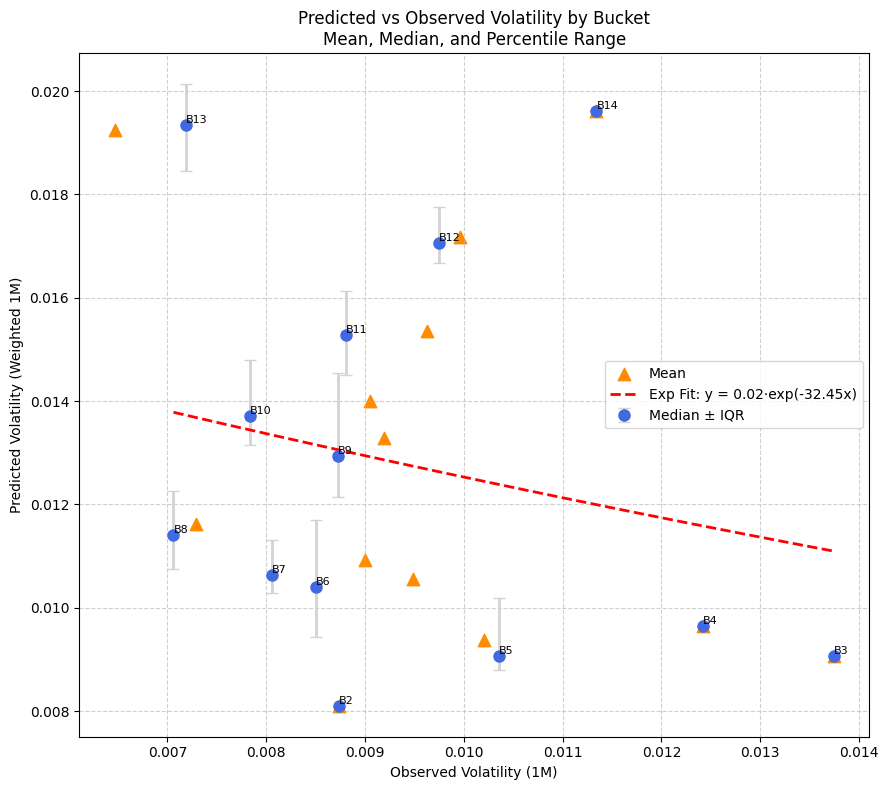

In [43]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

# --- Define exponential function ---
def exp_func(x, a, b):
    return a * np.exp(b * x)

# --- Choose fit variable (can switch between mean / median) ---
fit_x = bucket_stats["Observed_Vol_1M_median"]
fit_y = bucket_stats["WgtVol_1M_median"]


# --- Fit exponential curve ---
popt, _ = curve_fit(exp_func, fit_x, fit_y, p0=(1, 0.1))
x_fit = np.linspace(fit_x.min(), fit_x.max(), 200)
y_fit = exp_func(x_fit, *popt)

# --- Plot setup ---
plt.figure(figsize=(9, 8))

# 1️⃣ Median with error bars (IQR)
plt.errorbar(
    bucket_stats["Observed_Vol_1M_median"],
    bucket_stats["WgtVol_1M_median"],
    yerr=[
        bucket_stats["WgtVol_1M_median"] - bucket_stats["WgtVol_1M_p25"],
        bucket_stats["WgtVol_1M_p75"] - bucket_stats["WgtVol_1M_median"]
    ],
    fmt='o',
    color='royalblue',
    ecolor='lightgray',
    elinewidth=2,
    capsize=4,
    markersize=8,
    label='Median ± IQR'
)

# 2️⃣ Mean points
plt.scatter(
    bucket_stats["Observed_Vol_1M_mean"],
    bucket_stats["WgtVol_1M_mean"],
    color='darkorange',
    marker='^',
    s=80,
    label='Mean'
)

# 3️⃣ Exponential fit curve
plt.plot(
    x_fit, y_fit, 'r--', linewidth=2,
    label=f"Exp Fit: y = {popt[0]:.2f}·exp({popt[1]:.2f}x)"
)

# 4️⃣ Annotate buckets
for i, row in bucket_stats.iterrows():
    plt.text(row["Observed_Vol_1M_median"], row["WgtVol_1M_median"],
             f"B{int(row['VolBucket'])}", fontsize=8, va='bottom')

# --- Aesthetics ---
plt.xlabel("Observed Volatility (1M)")
plt.ylabel("Predicted Volatility (Weighted 1M)")
plt.title("Predicted vs Observed Volatility by Bucket\nMean, Median, and Percentile Range")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [44]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import warnings

# --- helper functions ---
def exp_func(x, a, b):
    """Exponential calibration function."""
    return a * np.exp(b * x)

def fit_exp_past_only(xpast, ypast, min_samples=20):
    """Fit y = a * exp(b x) using only past data. Return (a,b) or (np.nan,np.nan)."""
    if len(xpast) < min_samples:
        return (np.nan, np.nan)
    mask = np.isfinite(xpast) & np.isfinite(ypast)
    x = np.array(xpast)[mask]
    y = np.array(ypast)[mask]
    if len(x) < min_samples:
        return (np.nan, np.nan)
    try:
        p0 = (np.median(y), 0.1)
        popt, _ = curve_fit(exp_func, x, y, p0=p0, maxfev=20000)
        return popt  # a,b
    except Exception as e:
        warnings.warn(f"exp fit failed: {e}")
        return (np.nan, np.nan)

# --- inputs from your existing frames ---
# Motif-based predicted vol (weighted motif vol for each RebalDate)
motif_pred = rebal_weighted_stats.set_index("RebalDate")["WgtVol_1M"].sort_index()

# Realized next-1M vol (the "truth" you're forecasting)
observed = nw_forecast_df.set_index("RebalDate")["Observed_Vol_1M"].sort_index()

# Ensure same date intersection
common_dates = motif_pred.index.intersection(observed.index)
motif_pred = motif_pred.loc[common_dates]
observed = observed.loc[common_dates]

# --- expanding-window calibration ---
min_samples = 24    # require 2 years of monthly history before fitting
fit_window = None   # use all past (expanding window); set e.g. 60 for rolling 5y

records = []
a_prev, b_prev = np.nan, np.nan

for i, date in enumerate(motif_pred.index):
    past_mask = motif_pred.index < date
    if fit_window:
        # Rolling window variant (optional)
        past_mask &= motif_pred.index >= motif_pred.index[max(0, i - fit_window)]

    xpast = motif_pred.loc[past_mask].values
    ypast = observed.loc[past_mask].values

    a, b = fit_exp_past_only(xpast, ypast, min_samples=min_samples)
    if not np.isfinite(a) or not np.isfinite(b):
        # fallback: carry-forward previous parameters or simple ratio mapping
        if np.isfinite(a_prev) and np.isfinite(b_prev):
            a, b = a_prev, b_prev
        elif len(xpast) >= 5 and np.nanmean(xpast) > 0:
            ratio = np.nanmean(ypast / (xpast + 1e-12))
            a, b = ratio, 0.0
        else:
            a, b = np.nan, np.nan

    sigma_pred = motif_pred.loc[date]
    sigma_calib = a * np.exp(b * sigma_pred) if np.isfinite(a) and np.isfinite(b) else np.nan

    records.append({
        "RebalDate": date,
        "sigma_pred_motif": sigma_pred,
        "sigma_calib": sigma_calib,
        "a": a,
        "b": b
    })

    a_prev, b_prev = a, b  # carry forward

calib_df = pd.DataFrame(records).set_index("RebalDate")

# --- rolling percentile of calibrated vol (past-only window) ---
rolling_window = 60  # 5 years of monthly data
calib_df["pct_vol"] = (
    calib_df["sigma_calib"]
    .rolling(rolling_window, min_periods=12)
    .apply(lambda x: pd.Series(x).rank(pct=True).iloc[-1] if len(x) > 0 else np.nan)
)

# --- convert percentile vol into smooth equity allocation weight ---
# Exponential decay mapping: high vol -> low equity weight
w_min, w_max, k = 0.1, 1.0, 3.0
calib_df["w_equity_raw"] = w_min + (w_max - w_min) * np.exp(-k * calib_df["pct_vol"])

# Smooth allocations to avoid whipsaw
calib_df["w_equity"] = calib_df["w_equity_raw"].ewm(alpha=0.1, adjust=False).mean()

# Optional: split defensive bucket between gold and cash
calib_df["gold_share"] = np.where(calib_df["pct_vol"] < 0.5, 0.7,
                           np.where(calib_df["pct_vol"] < 0.8, 0.5, 0.3))
calib_df["w_gold"] = (1 - calib_df["w_equity"]) * calib_df["gold_share"]
calib_df["w_cash"] = 1 - calib_df["w_equity"] - calib_df["w_gold"]

# --- sanity checks ---
print(calib_df[["sigma_pred_motif","sigma_calib","pct_vol","w_equity","w_gold","w_cash"]].head(10))


            sigma_pred_motif  sigma_calib  pct_vol  w_equity  w_gold  w_cash
RebalDate                                                                   
2010-01-08          0.014687          NaN      NaN       NaN     NaN     NaN
2010-02-06          0.017916          NaN      NaN       NaN     NaN     NaN
2010-03-05          0.017297          NaN      NaN       NaN     NaN     NaN
2010-04-01          0.014648          NaN      NaN       NaN     NaN     NaN
2010-05-07          0.015360          NaN      NaN       NaN     NaN     NaN
2010-06-04          0.019356     0.653923      NaN       NaN     NaN     NaN
2010-07-02          0.014243     0.653923      NaN       NaN     NaN     NaN
2010-08-06          0.014541     0.653923      NaN       NaN     NaN     NaN
2010-09-03          0.020133     0.653923      NaN       NaN     NaN     NaN
2010-10-01          0.015087     0.653923      NaN       NaN     NaN     NaN


In [45]:
calib_df

,sigma_pred_motif,sigma_calib,a,b,pct_vol,w_equity_raw,w_equity,gold_share,w_gold,w_cash
RebalDate,,,,,,,,,,
2010-01-08,0.014687,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-02-06,0.017916,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-03-05,0.017297,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-04-01,0.014648,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-05-07,0.015360,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-05-02,0.009818,0.008380,0.006715,22.563070,0.050000,0.874637,0.608128,0.7,0.274311,0.117562
2025-06-06,0.010160,0.008486,0.006808,21.688296,0.150000,0.673865,0.614701,0.7,0.269709,0.115590
2025-07-04,0.010381,0.008501,0.006748,22.248231,0.166667,0.645878,0.617819,0.7,0.267527,0.114654


<Axes: xlabel='RebalDate'>

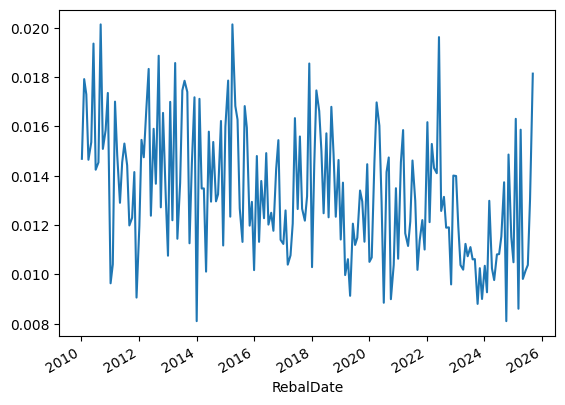

In [46]:
calib_df['sigma_pred_motif'].plot()

,sigma_pred_motif,sigma_calib,a,b,pct_vol,w_equity_raw,w_equity,gold_share,w_gold,w_cash
RebalDate,,,,,,,,,,
2010-01-08,0.014687,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-02-06,0.017916,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-03-05,0.017297,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-04-01,0.014648,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
2010-05-07,0.015360,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-05-02,0.009818,0.008380,0.006715,22.563070,0.050000,0.874637,0.608128,0.7,0.274311,0.117562
2025-06-06,0.010160,0.008486,0.006808,21.688296,0.150000,0.673865,0.614701,0.7,0.269709,0.115590
2025-07-04,0.010381,0.008501,0.006748,22.248231,0.166667,0.645878,0.617819,0.7,0.267527,0.114654


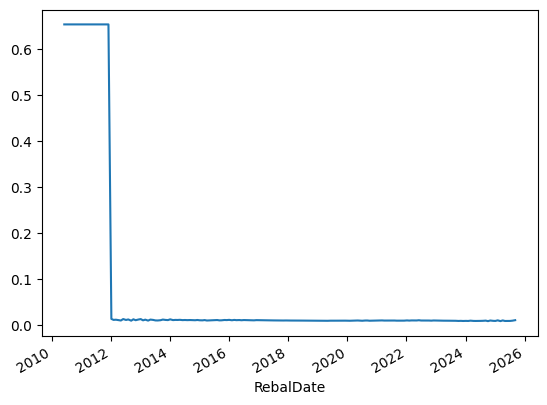

In [47]:
calib_df['sigma_calib'].plot()
calib_df

In [48]:
calib_df = calib_df[calib_df.index >= '2014-01-01']


<Axes: xlabel='RebalDate'>

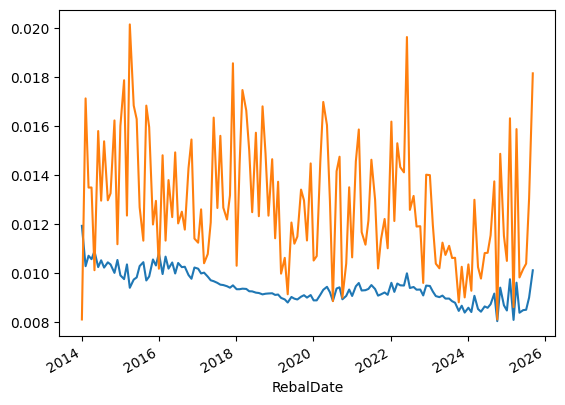

In [51]:
calib_df['sigma_calib'].plot()
calib_df['sigma_pred_motif'].plot()


<Axes: >

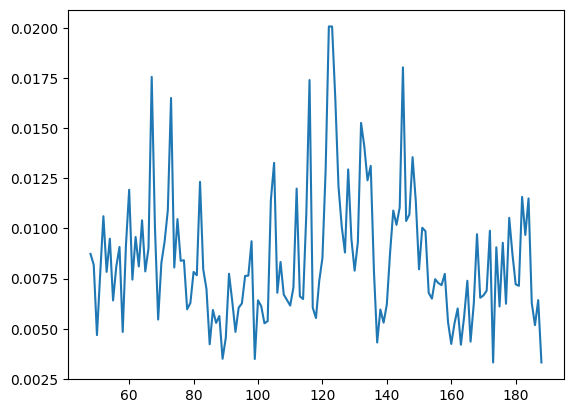

In [54]:
rebal_weighted_stats[rebal_weighted_stats['RebalDate']>='2014-01-01']['Observed_Vol_1M'].plot()